### 1. Importing raw data

In [1]:
import pandas as pd
df = pd.read_csv("Tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### 2. Info

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

### 3. Selected only needed columns

In [3]:
df = df[['airline_sentiment', 'negativereason', 'airline', 'retweet_count', 'text', 'tweet_created']]

df.head()

,airline_sentiment,negativereason,airline,retweet_count,text,tweet_created
0,neutral,NaN,Virgin America,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800
1,positive,NaN,Virgin America,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800
2,neutral,NaN,Virgin America,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800
3,negative,Bad Flight,Virgin America,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800
4,negative,Can't Tell,Virgin America,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800


### 4. Text Cleaning (NLP Preprocessing)

In [4]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)      # remove links
    text = re.sub(r"@\w+", "", text)         # remove @mentions
    text = re.sub(r"[^A-Za-z ]", "", text)   # remove special characters
    text = text.lower()                      # convert to lowercase
    return text

df['clean_text'] = df['text'].apply(clean_text)

### Checked

In [5]:
df[['text', 'clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


In [7]:
df.head()

,airline_sentiment,negativereason,airline,retweet_count,text,tweet_created,clean_text
0,neutral,NaN,Virgin America,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,what said
1,positive,NaN,Virgin America,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,plus youve added commercials to the experienc...
2,neutral,NaN,Virgin America,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,i didnt today must mean i need to take anothe...
3,negative,Bad Flight,Virgin America,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,its really aggressive to blast obnoxious ente...
4,negative,Can't Tell,Virgin America,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,and its a really big bad thing about it


### 5. Handling Missing Values

In [8]:
df.isnull().sum()

airline_sentiment       0
negativereason       5462
airline                 0
retweet_count           0
text                    0
tweet_created           0
clean_text              0
dtype: int64

In [9]:
df['negativereason'].fillna("No Reason", inplace=True)

C:\Users\Rupesh kumar mahto\AppData\Local\Temp\ipykernel_17196\249059615.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['negativereason'].fillna("No Reason", inplace=True)


In [10]:
df.isnull().sum()

airline_sentiment    0
negativereason       0
airline              0
retweet_count        0
text                 0
tweet_created        0
clean_text           0
dtype: int64

### 6. Sentiments Distribution

In [11]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

### 7. Sentiments Percentage

In [12]:
(df['airline_sentiment'].value_counts(normalize=True) * 100)

airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64

### 8. Sentiments by Airline

In [13]:
pd.crosstab(df['airline'], df['airline_sentiment'])

airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492
Virgin America,181,171,152


### 9. Negative Reasons 

In [14]:
df[df['airline_sentiment']=='negative']['negativereason'].value_counts()

negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

### 10. Bar Chart Showing sentiment distribution

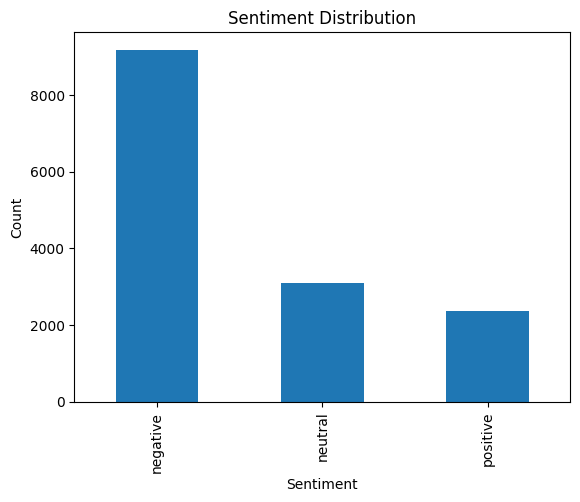

In [15]:
import matplotlib.pyplot as plt

df['airline_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### 11. Pie chart showing Sentiment share(%)

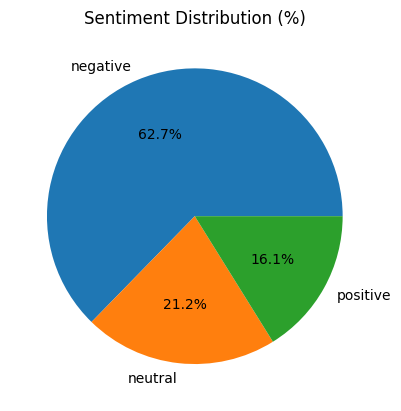

In [16]:
df['airline_sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution (%)")
plt.ylabel("")
plt.show()

### 12. Airline sentiment Comparison

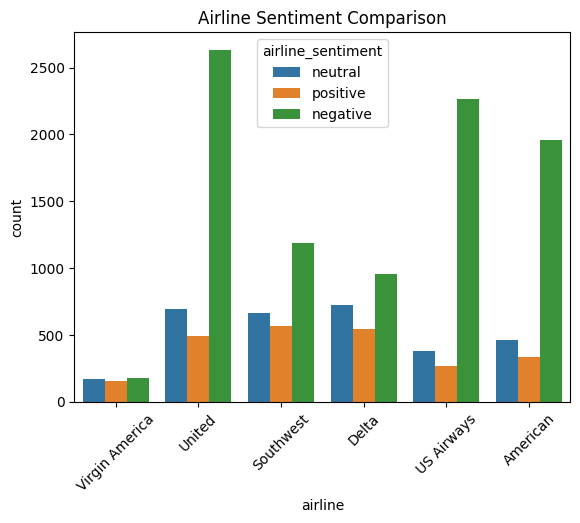

In [17]:
import seaborn as sns

sns.countplot(data=df, x='airline', hue='airline_sentiment')
plt.title("Airline Sentiment Comparison")
plt.xticks(rotation=45)
plt.show()

### 13. Negative Reasons Chart

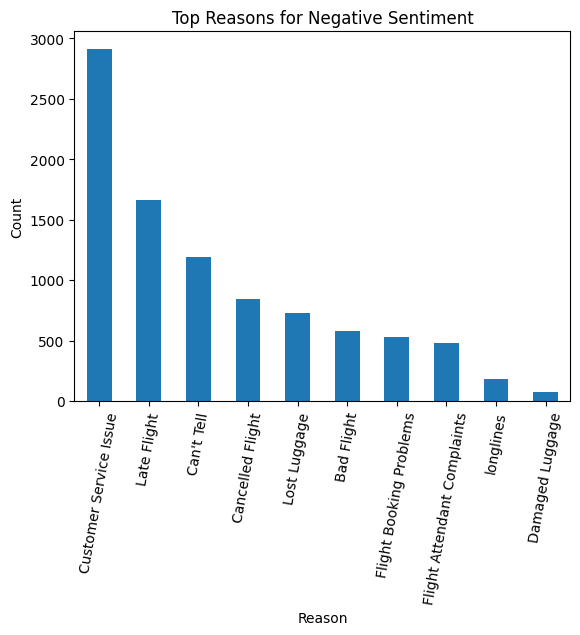

In [25]:
df[df['airline_sentiment']=='negative']['negativereason'].value_counts().plot(kind='bar')

plt.title("Top Reasons for Negative Sentiment")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.xticks(rotation=80)
plt.show()

 Airline vs Sentiment

### 15. Preparing Data for Power BI

In [26]:
df.to_csv("cleaned_airline_sentiment.csv", index=False)